In [ ]:
# %%
# =============================================================================
# Célula 1: Imports e Configurações para Análise
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker # Para formatar ticks em log
import seaborn as sns
import os
import traceback # Para log de erros, caso ocorram na leitura/plotagem

# --- Imports da Biblioteca (Apenas para Análise e Visualização) ---
try:
    from activetextclassification.analysis.cold_start_analyzer import (
        calculate_l0_sensitivity_stats,
        generate_l0_stats_latex_table
    )
    from activetextclassification.visualization.common_plots import (
        plot_filtered_evolutionary_boxplots, # <-- MUDOU AQUI
        plot_performance_trend_lines_combined, # <-- MUDOU AQUI
        plot_variability_trend
    )
    print("Módulos de análise e visualização da biblioteca activetextclassification importados.")
except ModuleNotFoundError as e:
    print(f"ERRO CRÍTICO: Falha ao importar módulos da biblioteca: {e}.")
    print("  Definindo funções dummy para permitir execução parcial do notebook.")
    def calculate_l0_sensitivity_stats(df, **kwargs): print("Dummy: calculate_l0_sensitivity_stats"); return pd.DataFrame()
    def generate_l0_stats_latex_table(df, **kwargs): print("Dummy: generate_l0_stats_latex_table"); return "% Tabela LaTeX não gerada"
    def plot_interval_boxplots(**kwargs): print("Dummy: plot_interval_boxplots")
    def plot_combined_performance_trends(**kwargs): print("Dummy: plot_combined_performance_trends")
    def plot_variability_trend(**kwargs): print("Dummy: plot_variability_trend")
except Exception as e:
    print(f"ERRO inesperado durante importação da biblioteca: {e}")
    raise e

# --- Autoreload (Opcional, útil se você estiver editando a biblioteca) ---
try:
    %load_ext autoreload
    %autoreload 2
    print("Autoreload ativado.")
except Exception: pass

# --- Configurações de Plotagem Seaborn (Opcional) ---
sns.set_theme(style="whitegrid", palette="pastel")
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

# --- ARQUIVO DE ENTRADA E PARÂMETROS PARA TÍTULOS/LEGENDAS ---
# <<< MUDE AQUI O CAMINHO E OS PARÂMETROS PARA CORRESPONDER AO SEU ARQUIVO DE RESULTADOS >>>
# RESULTS_DIR = "l0_random_impact_results_PVBin" # Diretório onde o arquivo de métricas foi salvo
INPUT_METRICS_FILE = OUTPUT_FILE_STATS = './data/sensibilidade/l0_random_impact_metrics_PVBin.xlsx' # Ou .csv

# Estes são para os títulos dos gráficos, devem refletir o experimento que gerou os dados
CLASSIFIER_TYPE_FOR_TITLES = "PVBin (1,2)-gram"
N_REPETITIONS_FOR_TITLES = 30 # Número de repetições usado para gerar os dados

# Arquivo de saída para a tabela LaTeX
OUTPUT_DIR_ANALYSIS = "l0_random_impact_analysis_outputs" # Pode ser o mesmo RESULTS_DIR ou outro
os.makedirs(OUTPUT_DIR_ANALYSIS, exist_ok=True)
OUTPUT_STATS_TABLE_LATEX = os.path.join(OUTPUT_DIR_ANALYSIS, f"l0_stats_table_analyzed.tex")
# <<< FIM MUDE AQUI >>>

print(f"Analisando arquivo de métricas: {INPUT_METRICS_FILE}")
print(f"Informações para títulos: Classificador='{CLASSIFIER_TYPE_FOR_TITLES}', Repetições='{N_REPETITIONS_FOR_TITLES}'")

Módulos de análise e visualização da biblioteca activetextclassification importados.
Autoreload ativado.
Analisando arquivo de métricas: ./data/sensibilidade/l0_random_impact_metrics_PVBin.xlsx
Informações para títulos: Classificador='PVBin (1,2)-gram', Repetições='30'


In [1]:
# %%
# =============================================================================
# Célula 2: Carregar DataFrame de Resultados das Simulações
# =============================================================================
print(f"\n--- Carregando Resultados de: {INPUT_METRICS_FILE} ---")
results_df = pd.DataFrame() # Inicializar

if not os.path.exists(INPUT_METRICS_FILE):
    print(f"ERRO: Arquivo de métricas '{INPUT_METRICS_FILE}' não encontrado.")
    # raise SystemExit("Arquivo de entrada não encontrado.") # Opcional: parar
else:
    try:
        if INPUT_METRICS_FILE.endswith('.xlsx'):
            results_df = pd.read_excel(INPUT_METRICS_FILE)
        elif INPUT_METRICS_FILE.endswith('.csv'):
            results_df = pd.read_csv(INPUT_METRICS_FILE)
        else:
            print(f"AVISO: Formato de arquivo não reconhecido para {INPUT_METRICS_FILE}. Tente .xlsx ou .csv.")

        if not results_df.empty:
            print(f"Resultados carregados com sucesso. Shape: {results_df.shape}")
            print("Colunas disponíveis:", results_df.columns.tolist())
            print("\nPrimeiras linhas dos resultados carregados:")
            display(results_df.head())
            # Verificações básicas de colunas esperadas
            expected_cols = ['l0_size', 'accuracy_on_population', 'f1_macro_on_population']
            if not all(col in results_df.columns for col in expected_cols):
                 missing = [col for col in expected_cols if col not in results_df.columns]
                 print(f"AVISO: Algumas colunas esperadas ({missing}) não encontradas no arquivo.")
        else:
            print(f"Arquivo '{INPUT_METRICS_FILE}' carregado, mas está vazio ou não pôde ser lido.")
            results_df = pd.DataFrame() # Garantir que é DF vazio

    except Exception as e:
        print(f"Erro ao carregar o arquivo de métricas: {type(e).__name__} - {e}")
        traceback.print_exc()
        results_df = pd.DataFrame() # Garantir que é DF vazio em caso de erro


--- Carregando Resultados de: ./data/sensibilidade/l0_random_impact_metrics_PVBin.xlsx ---
Resultados carregados com sucesso. Shape: (1410, 6)
Colunas disponíveis: ['l0_size', 'repetition', 'random_seed_used', 'accuracy_on_population', 'f1_macro_on_population', 'train_time_sec']

Primeiras linhas dos resultados carregados:


,l0_size,repetition,random_seed_used,accuracy_on_population,f1_macro_on_population,train_time_sec
0,10,1,52,0.078765,0.003923,0.000000
1,10,2,53,0.036107,0.002612,0.004020
2,10,3,54,0.025603,0.002411,0.004024
3,10,4,55,0.092106,0.003970,0.002009
4,10,5,56,0.059733,0.003279,0.005433


In [2]:
# %%
# =============================================================================
# Célula 3: Calcular Estatísticas Descritivas e Gerar Tabela LaTeX
# =============================================================================
full_stats_df = pd.DataFrame() # Inicializar

if not results_df.empty:
    print("\n--- Calculando Estatísticas Descritivas ---")
    # Usar a função da biblioteca
    full_stats_df = calculate_l0_sensitivity_stats(results_df, l0_size_column='l0_size')

    if not full_stats_df.empty:
        print("Estatísticas Descritivas Consolidadas:")
        display(full_stats_df.sort_values(by=['Métrica', 'l0_size'])) # Ordenar para melhor visualização

        print(f"\nGerando Tabela LaTeX para: {OUTPUT_STATS_TABLE_LATEX}")
        try:
            latex_table_string = generate_l0_stats_latex_table(
                stats_summary_df=full_stats_df,
                l0_size_column='l0_size',
                caption=f"Estatísticas Descritivas da Performance em Função do Tamanho de L0 (Classificador: {CLASSIFIER_TYPE_FOR_TITLES}). {N_REPETITIONS_FOR_TITLES} repetições por tamanho.",
                label="tab:l0_random_stats_analysis" # Label único para esta tabela
            )
            with open(OUTPUT_STATS_TABLE_LATEX, 'w', encoding='utf-8') as f:
                f.write(latex_table_string)
            print(f"Tabela LaTeX salva em: {OUTPUT_STATS_TABLE_LATEX}")
        except Exception as e_latex:
            print(f"Erro ao gerar tabela LaTeX: {e_latex}")
    else:
        print("Não foi possível calcular estatísticas (full_stats_df está vazio).")
else:
    print("DataFrame de resultados ('results_df') vazio. Nenhuma estatística calculada.")


--- Calculando Estatísticas Descritivas ---
Estatísticas Descritivas Consolidadas:


,Métrica,l0_size,Média,Mediana,DesvioPadrão,Mínimo,P25,P75,Máximo,IQR,CV (Mediana)
0,Acurácia,10,0.066649,0.068869,0.023793,0.025603,0.045918,0.088246,0.102171,0.042328,0.345485
1,Acurácia,20,0.105012,0.110059,0.023253,0.049388,0.089185,0.121807,0.138118,0.032622,0.211274
2,Acurácia,30,0.139531,0.138678,0.022874,0.095281,0.125312,0.155383,0.181395,0.030071,0.164945
3,Acurácia,40,0.159713,0.159447,0.022555,0.100274,0.144589,0.178245,0.191021,0.033656,0.141460
4,Acurácia,50,0.178486,0.179758,0.021830,0.124079,0.164435,0.198550,0.208496,0.034115,0.121440
...,...,...,...,...,...,...,...,...,...,...,...
89,F1-Macro,160000,0.688752,0.688245,0.003703,0.681760,0.686785,0.690993,0.700429,0.004208,0.005380
90,F1-Macro,170000,0.693007,0.693140,0.002942,0.687723,0.690346,0.695466,0.698889,0.005120,0.004244
91,F1-Macro,180000,0.698289,0.698678,0.002964,0.692119,0.696257,0.700335,0.703808,0.004078,0.004242
92,F1-Macro,190000,0.700854,0.700615,0.002355,0.694611,0.699792,0.701759,0.706399,0.001968,0.003361



Gerando Tabela LaTeX para: l0_random_impact_analysis_outputs\l0_stats_table_analyzed.tex
Tabela LaTeX salva em: l0_random_impact_analysis_outputs\l0_stats_table_analyzed.tex



--- GRÁFICO 1a: Boxplot Filtrado da Acurácia ---

--- Gerando Boxplot Filtrado para: accuracy_on_population ---


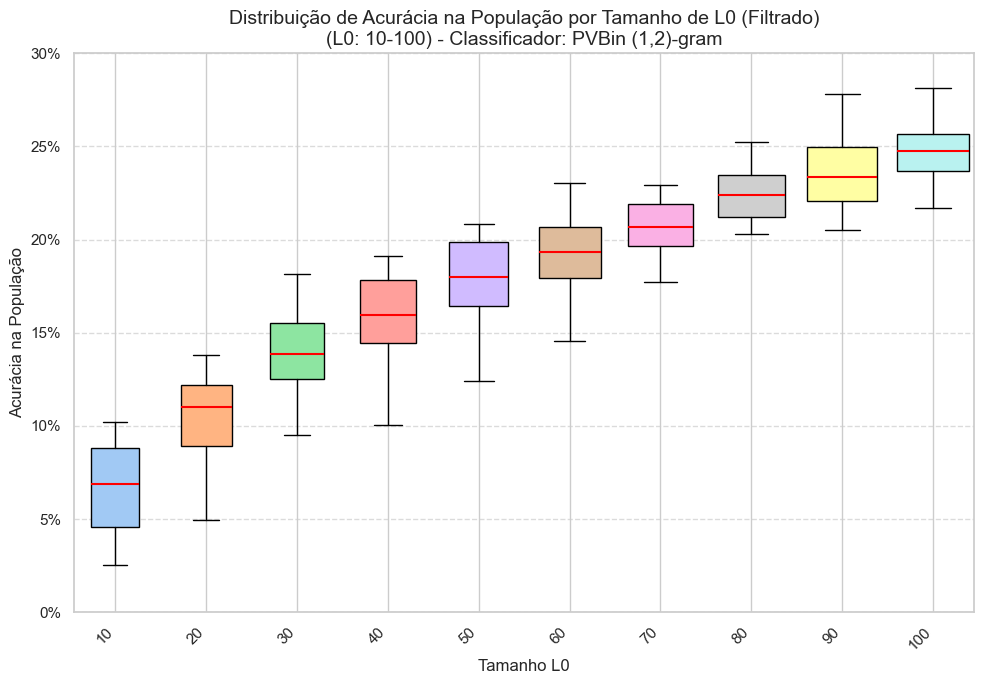


--- GRÁFICO 1a: Boxplot Filtrado da Acurácia ---

--- Gerando Boxplot Filtrado para: accuracy_on_population ---


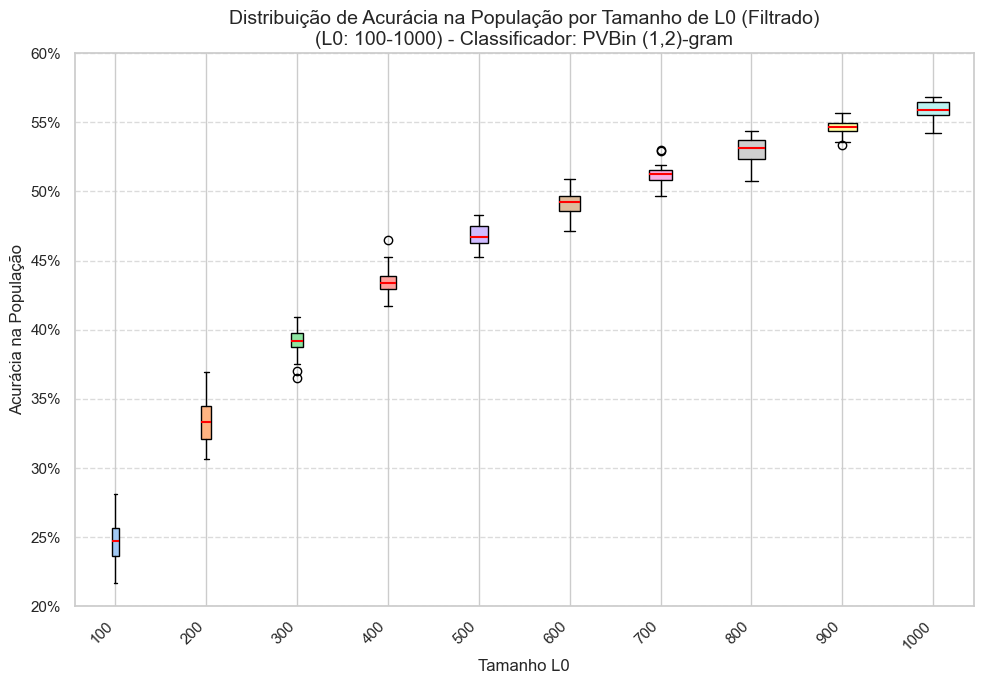


--- GRÁFICO 1a: Boxplot Filtrado da Acurácia ---

--- Gerando Boxplot Filtrado para: accuracy_on_population ---


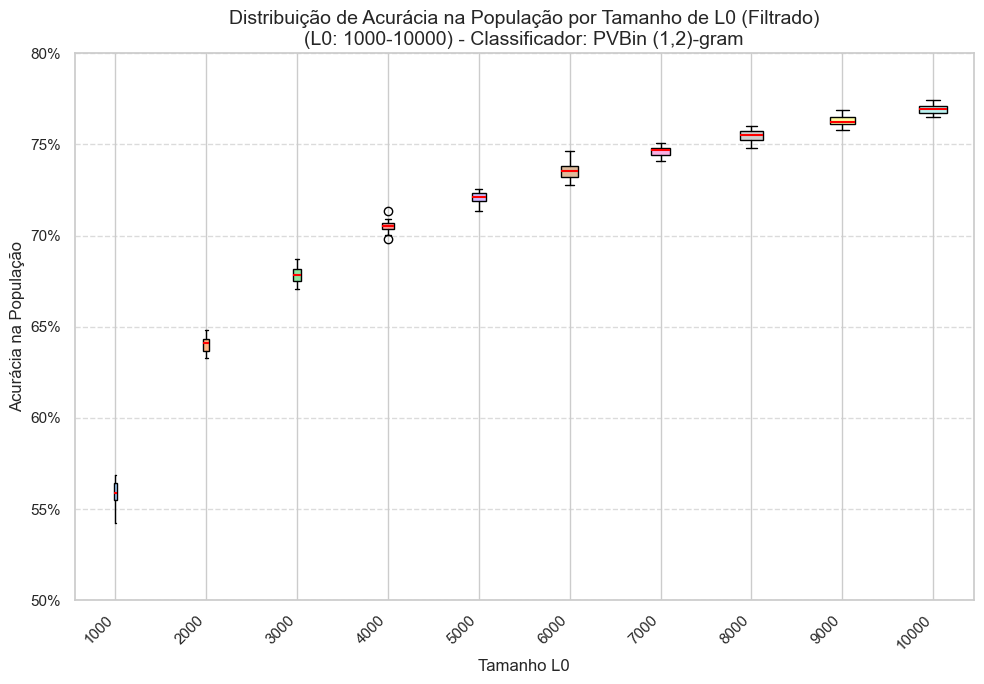


--- GRÁFICO 1a: Boxplot Filtrado da Acurácia ---

--- Gerando Boxplot Filtrado para: accuracy_on_population ---


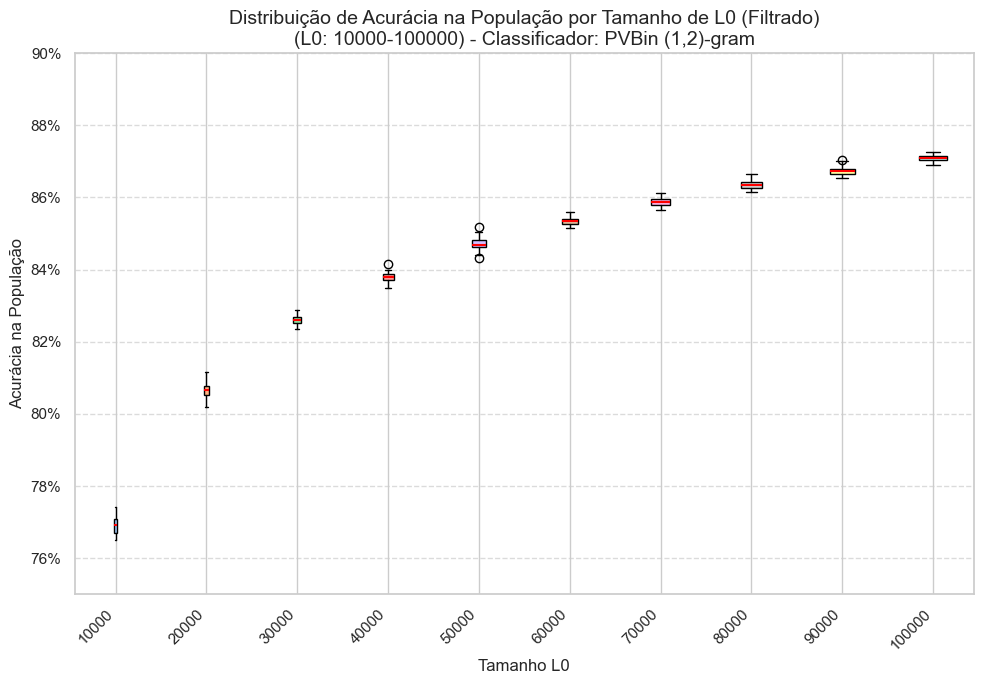


--- GRÁFICO 1a: Boxplot Filtrado da Acurácia ---

--- Gerando Boxplot Filtrado para: accuracy_on_population ---


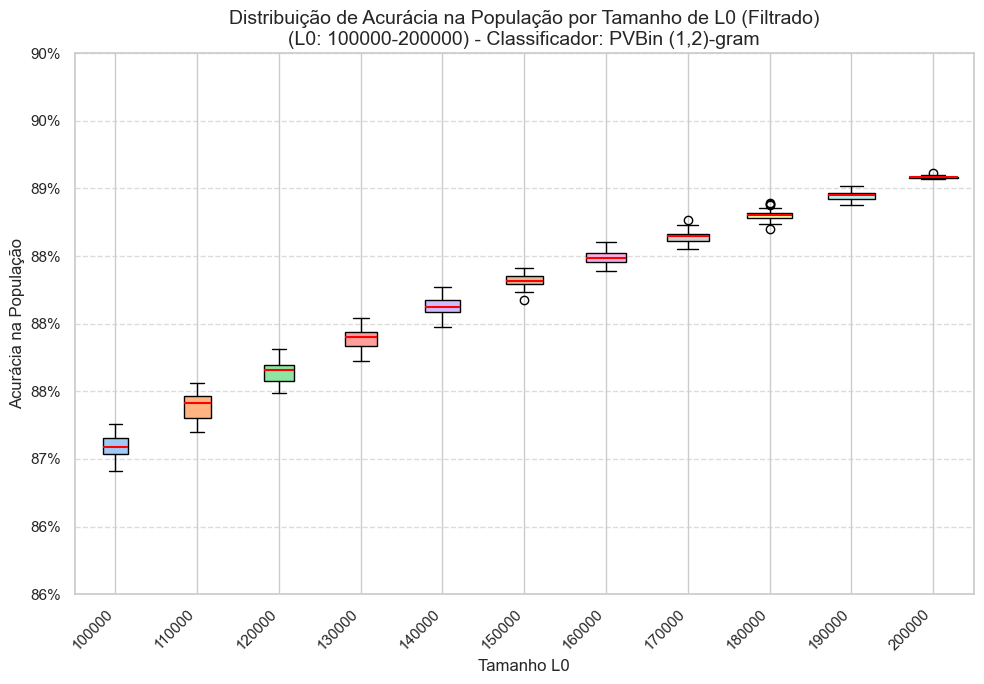

In [3]:
# %%
# =============================================================================
# Célula 6: GRÁFICO 1 - Boxplot FILTRADO da Acurácia
# =============================================================================
intervalos = [
    (1,10,100,0,.3),
    (2,100,1000,0.2,.6),
    (3,1000,10000,0.5,.8),
    (4,10000,100000,0.75,.9),
    (5,100000,200000,.86,.9)
]
for i, xmin, xmax, ymin, ymax in intervalos:
    if 'results_df' in locals() and not results_df.empty:
        print("\n--- GRÁFICO 1a: Boxplot Filtrado da Acurácia ---")
        # --- DEFINIR INTERVALO NO JUPYTER ---
        acc_plot_min_l0 = xmin    # Exemplo: De 10
        acc_plot_max_l0 = xmax  # Exemplo: Até 1000
        # Para plotar todos, defina como None:
        # acc_plot_min_l0 = None
        # acc_plot_max_l0 = None
        # --- FIM DEFINIR INTERVALOS ---

        plot_filtered_evolutionary_boxplots(
            results_df=results_df,
            metric_column='accuracy_on_population',
            l0_size_column='l0_size',
            title_suffix=f"(L0: {acc_plot_min_l0 or 'Min'}-{acc_plot_max_l0 or 'Max'}) - Classificador: {CLASSIFIER_TYPE_FOR_TITLES}",
            xlabel=f'Tamanho L0',
            ylabel='Acurácia na População',
            figsize=(max(10, results_df[results_df['l0_size'].between(acc_plot_min_l0 or 0, acc_plot_max_l0 or np.inf)]['l0_size'].nunique() * 0.6), 7),
            x_value_min=acc_plot_min_l0,
            x_value_max=acc_plot_max_l0,
            y_min=ymin, y_max=ymax
        )
    else:
        print("DataFrame 'results_df' não disponível para Gráfico 1a.")


--- GRÁFICO 1b: Boxplot Filtrado do F1-Score ---

--- Gerando Boxplot Filtrado para: f1_macro_on_population ---


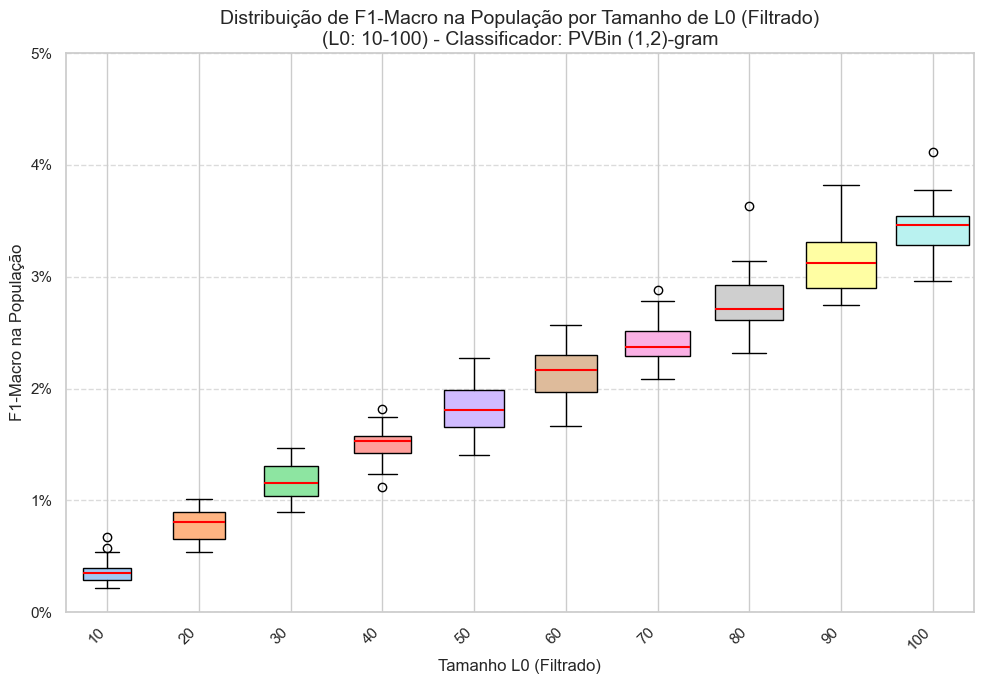


--- GRÁFICO 1b: Boxplot Filtrado do F1-Score ---

--- Gerando Boxplot Filtrado para: f1_macro_on_population ---


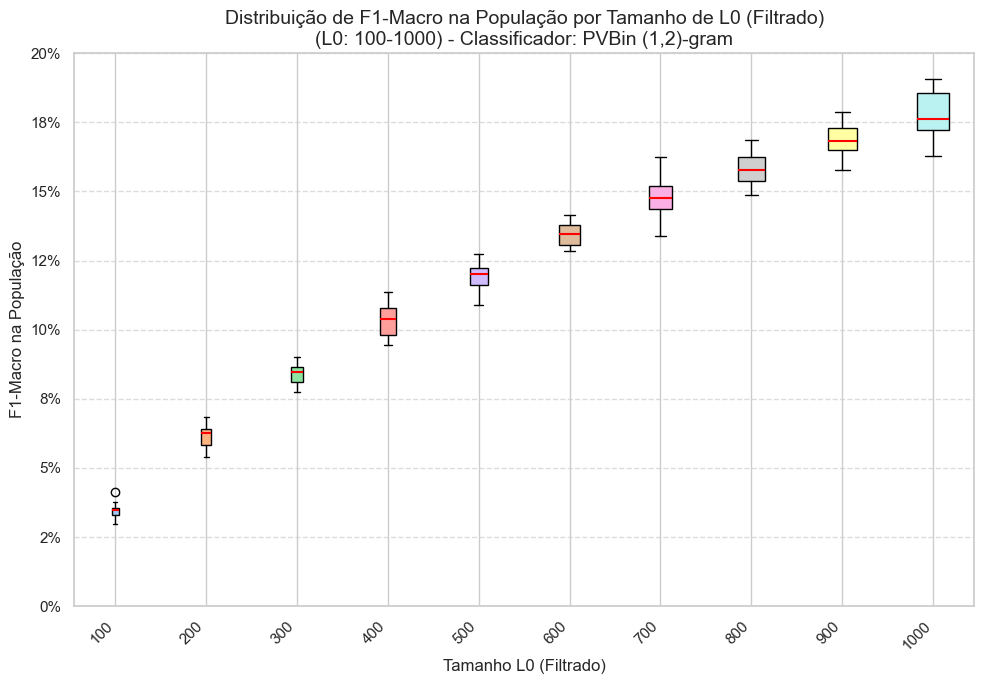


--- GRÁFICO 1b: Boxplot Filtrado do F1-Score ---

--- Gerando Boxplot Filtrado para: f1_macro_on_population ---


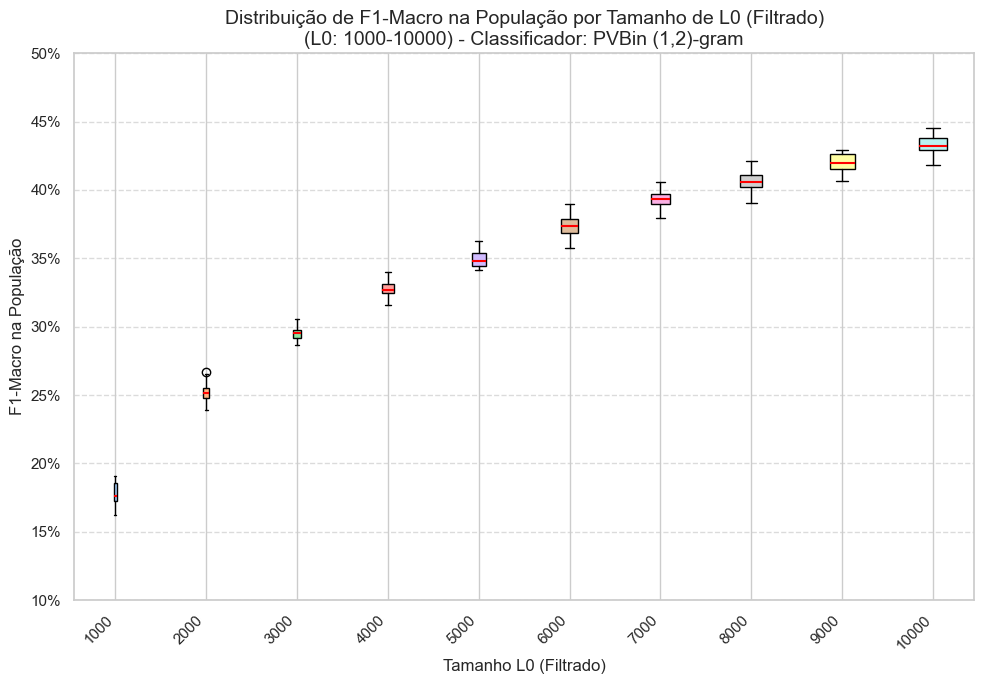


--- GRÁFICO 1b: Boxplot Filtrado do F1-Score ---

--- Gerando Boxplot Filtrado para: f1_macro_on_population ---


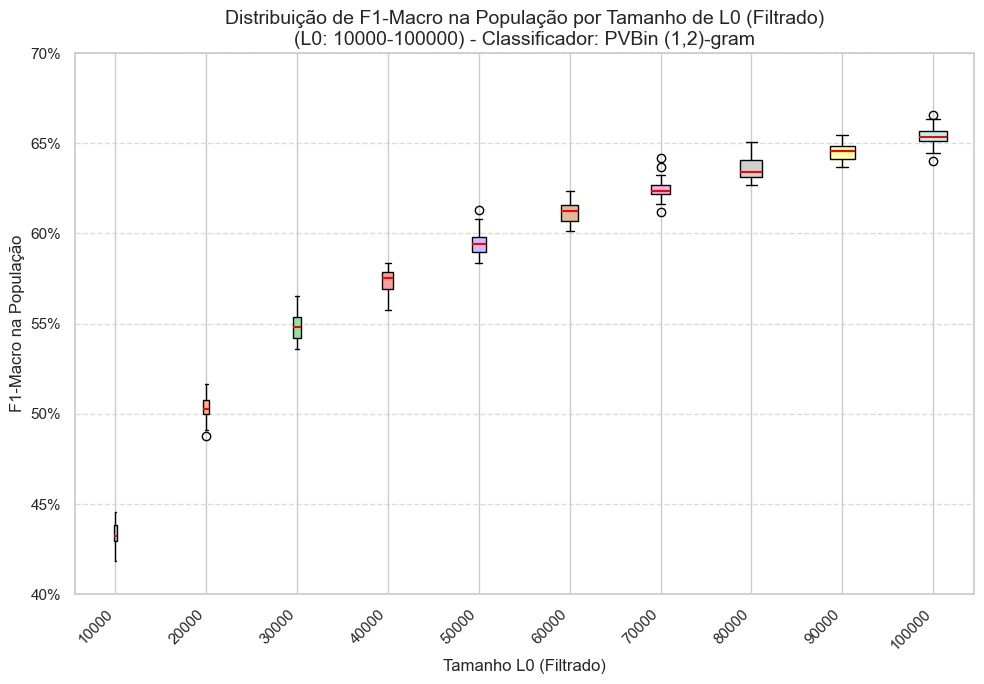


--- GRÁFICO 1b: Boxplot Filtrado do F1-Score ---

--- Gerando Boxplot Filtrado para: f1_macro_on_population ---


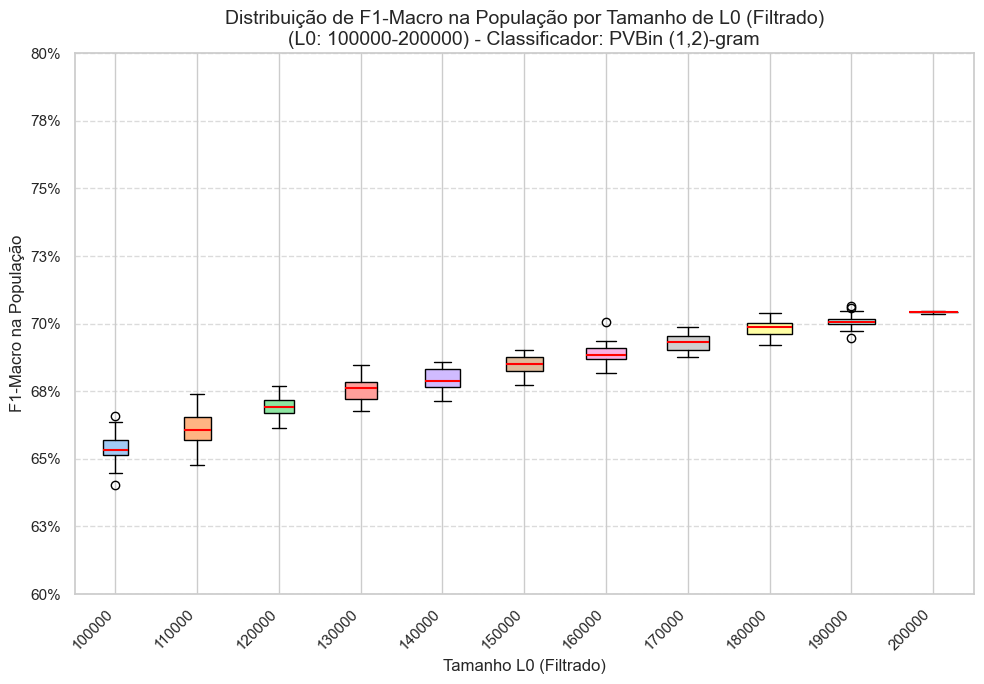

In [4]:
# %%
# =============================================================================
# Célula 7: GRÁFICO 1 - Boxplot FILTRADO do F1-Score
# =============================================================================
intervalos = [
    (1,10,100,0,.05),
    (2,100,1000,0,.2),
    (3,1000,10000,0.1,.5),
    (4,10000,100000,0.4,.7),
    (5,100000,200000,0.6,.8)
]
for i, xmin, xmax, ymin, ymax in intervalos:
    if 'results_df' in locals() and not results_df.empty:
        print("\n--- GRÁFICO 1b: Boxplot Filtrado do F1-Score ---")
        # --- DEFINIR INTERVALO NO JUPYTER ---
        f1_plot_min_l0 = xmin
        f1_plot_max_l0 = xmax
        # --- FIM DEFINIR INTERVALOS ---

        plot_filtered_evolutionary_boxplots(
            results_df=results_df,
            metric_column='f1_macro_on_population',
            l0_size_column='l0_size',
            title_suffix=f"(L0: {f1_plot_min_l0 or 'Min'}-{f1_plot_max_l0 or 'Max'}) - Classificador: {CLASSIFIER_TYPE_FOR_TITLES}",
            xlabel=f'Tamanho L0 (Filtrado)',
            ylabel='F1-Macro na População',
            figsize=(max(10, results_df[results_df['l0_size'].between(f1_plot_min_l0 or 0, f1_plot_max_l0 or np.inf)]['l0_size'].nunique() * 0.6), 7),
            x_value_min=f1_plot_min_l0,
            x_value_max=f1_plot_max_l0,
            y_min=ymin, y_max=ymax
        )
    else:
        print("DataFrame 'results_df' não disponível para Gráfico 1b.")

In [21]:
def plot_performance_trend_lines_combined(
    stats_df_long,
    l0_size_column='l0_size',
    title="Tendência da Performance por Tamanho de L0",
    xlabel="Tamanho da Amostra Inicial (L0)",
    ylabel="Performance",
    figsize=(14, 7),
    use_log_scale_x=False,
    show_markers=True,
    plot_min_max_fill=True,
    y_min=0.0, y_max=1.01,
    metrics_to_plot=None,
    format_y_as_percent=True
):
    """ Plota linhas de tendência para múltiplas métricas... """
    print(f"\n--- Gerando Gráfico Combinado de Tendências (Log X: {use_log_scale_x}) ---") # Adicionado Log X ao print
    if stats_df_long is None or stats_df_long.empty: print("AVISO: DF stats vazio."); return
    if l0_size_column not in stats_df_long.columns: print(f"AVISO: Coluna '{l0_size_column}' não encontrada."); return
    if metrics_to_plot is None: metrics_to_plot = {'Acurácia': 'Acurácia Média', 'F1-Macro': 'F1-Macro Médio'}

    plt.figure(figsize=figsize)
    palette = sns.color_palette("husl", n_colors=len(metrics_to_plot)); color_idx = 0
    marker_style = '.' if show_markers else None

    for metric_name_in_df, legend_label_mean in metrics_to_plot.items():
        metric_data = stats_df_long[stats_df_long['Métrica'] == metric_name_in_df].sort_values(by=l0_size_column)
        if metric_data.empty: print(f"AVISO: Sem dados para '{metric_name_in_df}'."); continue
        color = palette[color_idx % len(palette)]; color_idx += 1
        
        # Garantir que as colunas de métricas são numéricas antes de plotar
        mean_series = pd.to_numeric(metric_data.get('Média'), errors='coerce')
        min_series = pd.to_numeric(metric_data.get('Mínimo'), errors='coerce')
        max_series = pd.to_numeric(metric_data.get('Máximo'), errors='coerce')
        median_series = pd.to_numeric(metric_data.get('Mediana'), errors='coerce') # Adicionado para flexibilidade

        if not mean_series.dropna().empty:
             plt.plot(metric_data[l0_size_column], mean_series, label=legend_label_mean, marker=marker_style, linewidth=2, color=color)
        
        # Opcional: plotar mediana também
        # if not median_series.dropna().empty:
        #      plt.plot(metric_data[l0_size_column], median_series, label=f'{metric_name_in_df} Mediana', marker=marker_style, linestyle='--', color=color)

        if plot_min_max_fill and not min_series.dropna().empty and not max_series.dropna().empty:
             min_v = min_series.ffill().bfill(); max_v = max_series.ffill().bfill()
             plt.fill_between(metric_data[l0_size_column], min_v, max_v, color=color, alpha=0.15, label=f'Intervalo Min-Max {metric_name_in_df}')
        elif not min_series.dropna().empty:
             plt.plot(metric_data[l0_size_column], min_series, label=f'{metric_name_in_df} Mínima', marker=marker_style, linestyle=':', color=color, alpha=0.7)
        elif not max_series.dropna().empty: # Correção: Era elif, mudei para if para plotar Máximo mesmo se Mínimo não existir
             plt.plot(metric_data[l0_size_column], max_series, label=f'{metric_name_in_df} Máxima', marker=marker_style, linestyle=':', color=color, alpha=0.7)

    plt.title(title, fontsize=14); plt.xlabel(xlabel); plt.ylabel(ylabel)
    plt.legend(loc='lower right'); plt.grid(True, linestyle='--', alpha=0.7)
    if format_y_as_percent: plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))

    # --- LÓGICA DE TICKS DO EIXO X ATUALIZADA ---
    unique_x_values_plot = sorted(list(stats_df_long[l0_size_column].unique()))
    if unique_x_values_plot: # Apenas se houver valores
        if use_log_scale_x:
            plt.xscale('log')
            # Tentar definir ticks logarítmicos de forma mais inteligente
            min_x, max_x = unique_x_values_plot[0], unique_x_values_plot[-1]
            log_ticks_candidates = [10, 20, 30, 50, 70, 100, 200, 300, 500, 700, 1000,
                                    2000, 3000, 5000, 7000, 10000, 20000, 50000, 100000, 200000]
            tick_pos = [t for t in log_ticks_candidates if t >= min_x and t <= max_x]

            # Garantir que o primeiro e o último valor original estejam nos ticks
            if not tick_pos or (tick_pos and tick_pos[-1] < max_x and max_x not in tick_pos):
                tick_pos.append(max_x)
            if tick_pos and tick_pos[0] > min_x and min_x not in tick_pos :
                tick_pos.insert(0,min_x)
            tick_pos = sorted(list(set(tick_pos))) # Remover duplicatas e ordenar

            plt.xticks(tick_pos, rotation=45, ha='right')
            plt.gca().xaxis.set_major_formatter(mticker.ScalarFormatter())
            plt.gca().xaxis.get_major_formatter().set_scientific(False)
            plt.gca().tick_params(axis='x', which='minor', bottom=False, top=False) # Limpar minor ticks
        else: # Escala Linear
            # Para escala linear, selecionar um número razoável de ticks
            num_desired_ticks = 10 # Quantos ticks queremos aproximadamente
            if len(unique_x_values_plot) <= num_desired_ticks + 2 : # Se poucos, mostrar todos
                tick_pos = unique_x_values_plot
            else:
                # Selecionar ticks distribuídos, incluindo o primeiro e o último
                print("oi")
                indices = np.linspace(0, len(unique_x_values_plot) - 1, num_desired_ticks, dtype=int)
                tick_pos = [unique_x_values_plot[i] for i in indices]
                tick_pos = unique_x_values_plot[27:] 
                if unique_x_values_plot[0] not in tick_pos: tick_pos.insert(0, unique_x_values_plot[0])
                if unique_x_values_plot[-1] not in tick_pos: tick_pos.append(unique_x_values_plot[-1])
                
            plt.xticks(tick_pos, rotation=45, ha='right')
    # --- FIM LÓGICA DE TICKS ---


    if y_min is not None or y_max is not None: plt.ylim(bottom=y_min, top=y_max)
    elif format_y_as_percent: plt.ylim(bottom=0.0, top=1.01)
    else: plt.ylim(bottom=0) # Default para performance se não for percentual
    plt.tight_layout(); plt.show()


--- GRÁFICO 2: Linhas de Tendência Combinadas (Acurácia e F1) ---

--- Gerando Gráfico Combinado de Tendências (Log X: True) ---


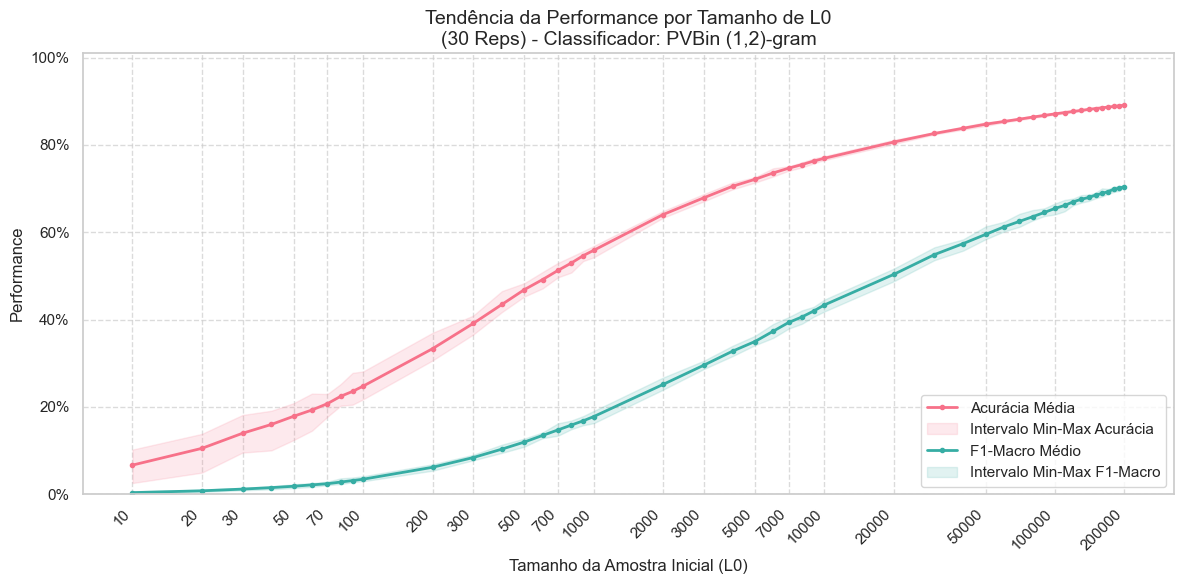


--- GRÁFICO 2 (Escala Linear X): Linhas de Tendência Combinadas (Acurácia e F1) ---

--- Gerando Gráfico Combinado de Tendências (Log X: False) ---
oi


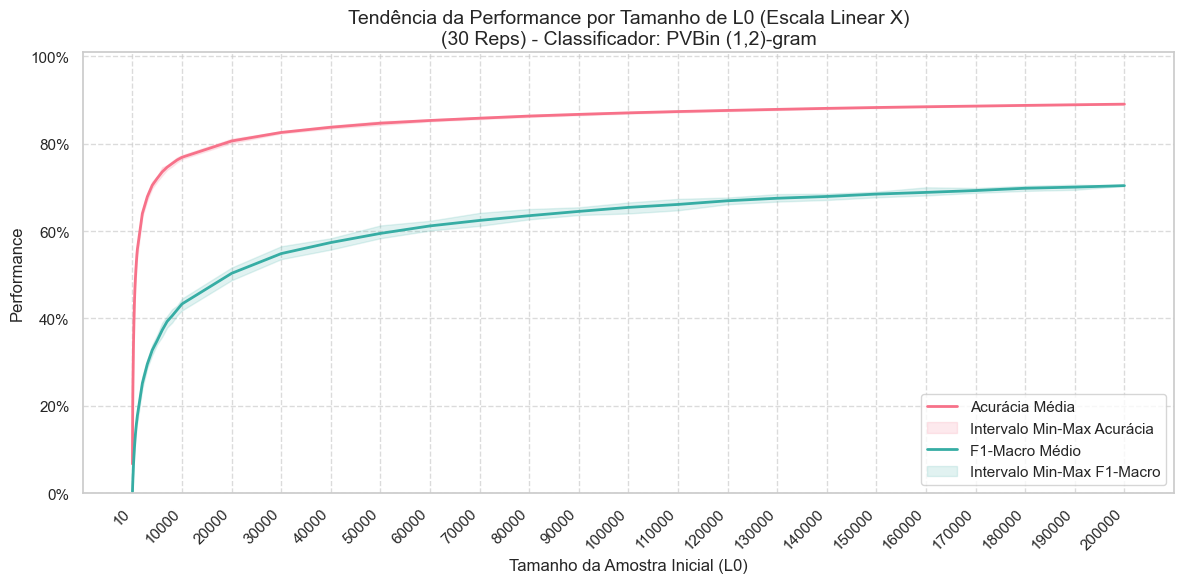

In [22]:
# %%
# =============================================================================
# Célula 8: GRÁFICO 2 - Linhas de Tendência Combinadas (Acc e F1)
# =============================================================================
if 'full_stats_df' in locals() and not full_stats_df.empty:
    print("\n--- GRÁFICO 2: Linhas de Tendência Combinadas (Acurácia e F1) ---")
    plot_performance_trend_lines_combined( # Nome da função atualizado
        stats_df_long=full_stats_df, # Passar o DataFrame longo com coluna 'Métrica'
        metrics_to_plot={'Acurácia': 'Acurácia Média', 'F1-Macro': 'F1-Macro Médio'}, # Especificar métricas
        l0_size_column='l0_size',
        title=f'Tendência da Performance por Tamanho de L0\n({N_REPETITIONS_FOR_TITLES} Reps) - Classificador: {CLASSIFIER_TYPE_FOR_TITLES}',
        use_log_scale_x=True, # Opção para escala log
        show_markers=True,
        plot_min_max_fill=True,
        y_min=0.0, y_max=1.01,
        figsize=(12,6)
    )
    # Plotar também em escala linear para o eixo X
    print("\n--- GRÁFICO 2 (Escala Linear X): Linhas de Tendência Combinadas (Acurácia e F1) ---")
    plot_performance_trend_lines_combined(
        stats_df_long=full_stats_df,
        metrics_to_plot={'Acurácia': 'Acurácia Média', 'F1-Macro': 'F1-Macro Médio'},
        l0_size_column='l0_size',
        title=f'Tendência da Performance por Tamanho de L0 (Escala Linear X)\n({N_REPETITIONS_FOR_TITLES} Reps) - Classificador: {CLASSIFIER_TYPE_FOR_TITLES}',
        use_log_scale_x=False, # Escala Linear
        show_markers=False,
        plot_min_max_fill=True,
        y_min=0.0, y_max=1.01,
        figsize=(12,6)
    )
else:
    print("DataFrame 'full_stats_df' não disponível para Gráfico 2.")


--- GRÁFICO 3: Tendências de Variabilidade ---

--- Gerando Gráfico de Tendência de Variabilidade para: ['Acurácia', 'F1-Macro'] ---


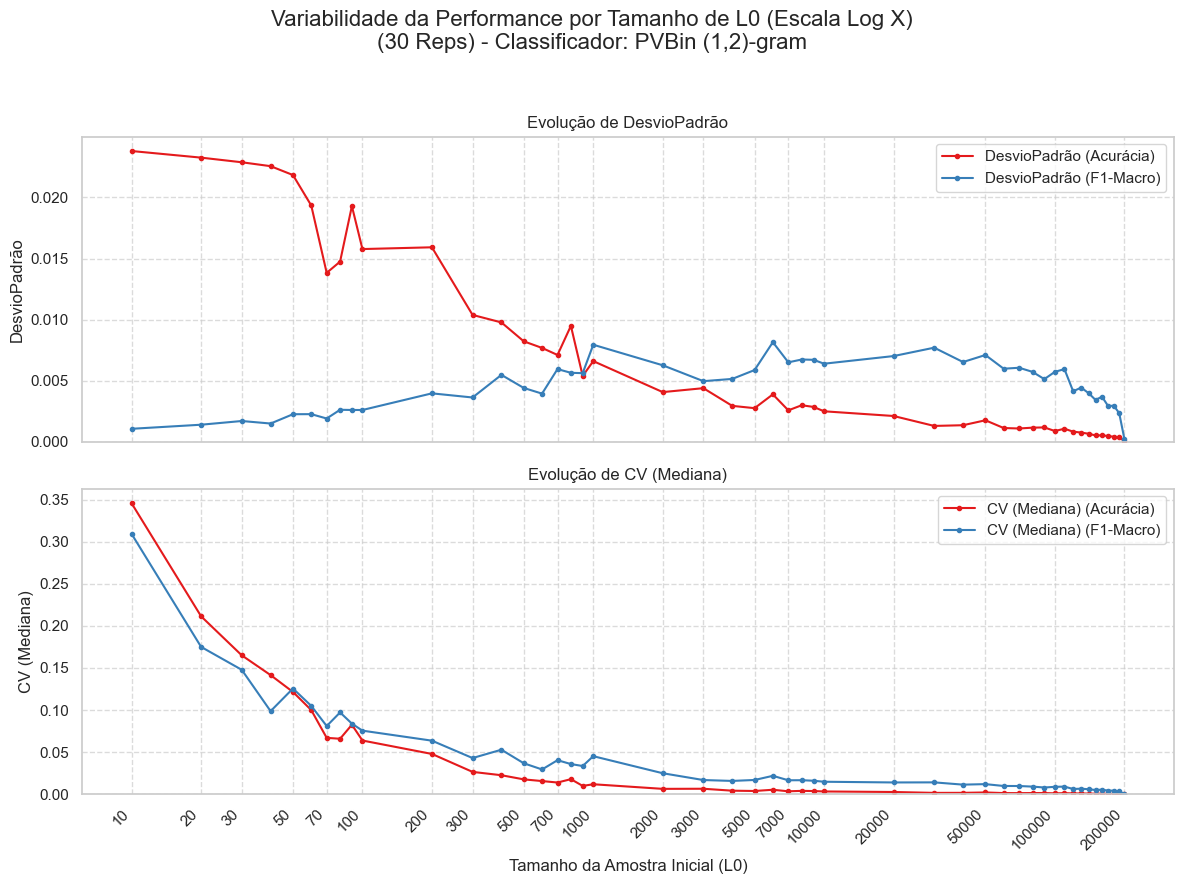


--- GRÁFICO 3 (Escala Linear X): Tendências de Variabilidade ---

--- Gerando Gráfico de Tendência de Variabilidade para: ['Acurácia', 'F1-Macro'] ---


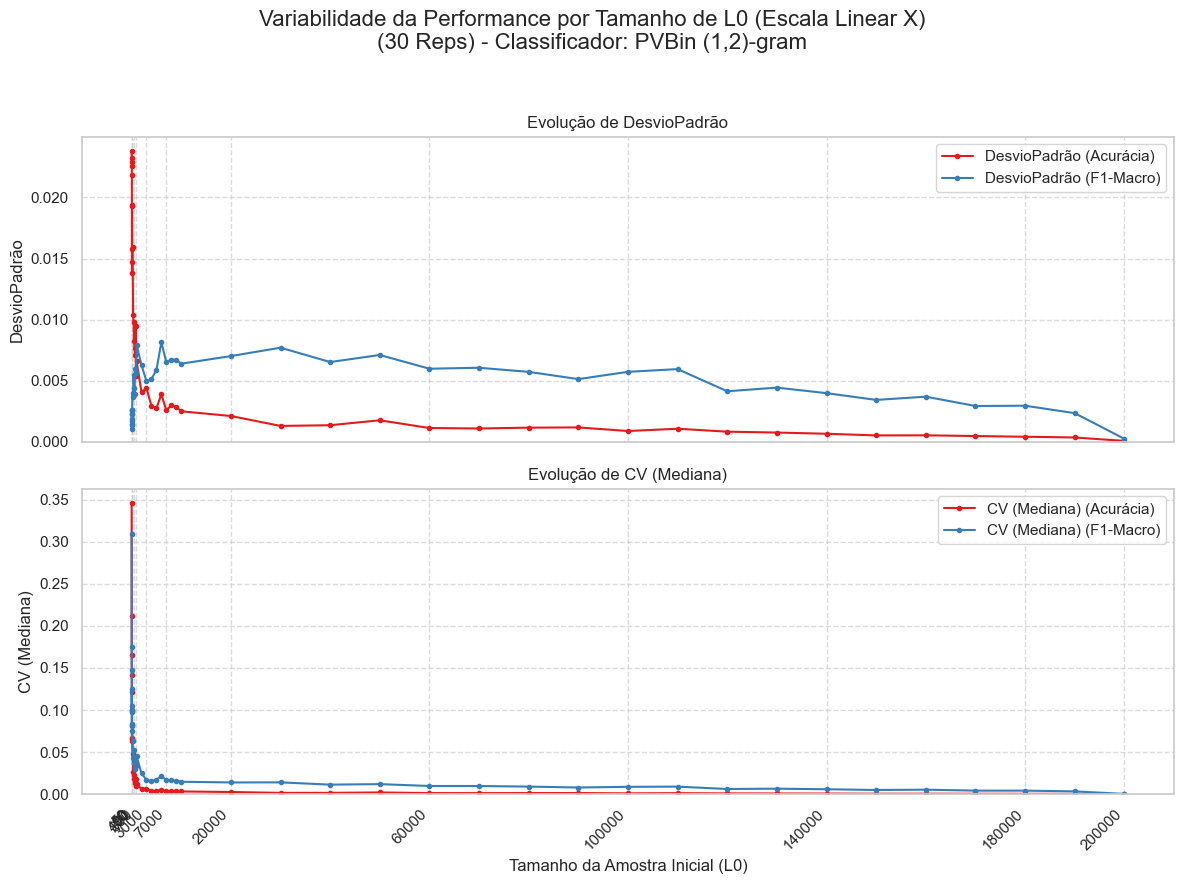

In [6]:
# %%
# =============================================================================
# Célula 9: GRÁFICO 3 - Variabilidade (Desvio Padrão e Coeficiente de Variação)
# =============================================================================
if 'full_stats_df' in locals() and not full_stats_df.empty:
    print("\n--- GRÁFICO 3: Tendências de Variabilidade ---")
    # Plotar com escala log no eixo X
    plot_variability_trend(
        stats_df=full_stats_df, # DataFrame longo
        variability_metrics=['DesvioPadrão', 'CV (Mediana)'],
        metric_names=['Acurácia', 'F1-Macro'],
        l0_size_column='l0_size',
        title=f'Variabilidade da Performance por Tamanho de L0 (Escala Log X)\n({N_REPETITIONS_FOR_TITLES} Reps) - Classificador: {CLASSIFIER_TYPE_FOR_TITLES}',
        use_log_scale_x=True, # Escala Log
        show_markers=True,
        figsize=(12,9)
    )
    # Plotar com escala linear no eixo X
    print("\n--- GRÁFICO 3 (Escala Linear X): Tendências de Variabilidade ---")
    plot_variability_trend(
        stats_df=full_stats_df,
        variability_metrics=['DesvioPadrão', 'CV (Mediana)'],
        metric_names=['Acurácia', 'F1-Macro'],
        l0_size_column='l0_size',
        title=f'Variabilidade da Performance por Tamanho de L0 (Escala Linear X)\n({N_REPETITIONS_FOR_TITLES} Reps) - Classificador: {CLASSIFIER_TYPE_FOR_TITLES}',
        use_log_scale_x=False, # Escala Linear
        show_markers=True,
        figsize=(12,9)
    )
else:
    print("DataFrame 'full_stats_df' não disponível para Gráfico 3.")